# Working with MRI Data in Python

In this tutorial, you will learn how to work with *NIfTI* files — the standard format for storing MRI data — using the Python package *Nibabel*.  

We assume you are already familiar with basic Python syntax as well as core NumPy and Matplotlib functionality. If you need a refresher, see [this overview](https://neuroimaging-data-science.org/content/003-programming/001-python-language.html).

**Learning objectives**  
- Understand what the NIfTI format is and why it is used  
- Learn how to load, inspect, and manipulate NIfTI files in Python  
- Practise converting MRI data into NumPy arrays for analysis  

**Estimated time to complete:** 1–2 hours  

**Credits:**  
- Originally developed by Lukas Snoek (2019)  
- Updated and extended by Joe Bathelt (2024 & 2025)  

## What is NIfTI?

Different MRI scanner manufacturers (e.g., Philips, Siemens, GE) use their own proprietary data formats. For example, at the University of Amsterdam, Philips scanners typically export data as **PAR/REC** files.  

To make data easier to share and process across different software tools, the Neuroimaging Informatics Technology Initiative developed a standard format called **NIfTI**. Today, NIfTI is supported by nearly all major neuroimaging packages.

In most (f)MRI preprocessing workflows, the first step is to convert scanner-specific formats (e.g., PAR/REC, DICOM) into NIfTI. This conversion is outside the scope of this course, but the recommended tool is **dcm2niix**.

In this tutorial, you will work with NIfTI files (also called *NIfTI images*), which are typically stored as:  
- `.nii` (uncompressed)  
- `.nii.gz` (compressed)  

To explore NIfTI images in Python, we will use the [nibabel](https://nipy.org/nibabel/) library. This package allows you to read, load, and convert NIfTI images into NumPy arrays, making them easy to analyse.

In [3]:
# Let's load some other packages we need
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import nibabel as nib # common way of importing nibabel

In [3]:
import nilearn; nilearn.__version__

'0.10.4'

In [4]:
import os
import urllib.request

def download_file(url, outfile):
    """Download file from URL if not already present."""
    if not os.path.exists(outfile):
        print(f"Downloading {outfile}...")
        urllib.request.urlretrieve(url, outfile)
        print(f"Saved as {outfile}")
    else:
        print(f"{outfile} already exists, skipping download.")

# Downloading some required data
download_file(
    "https://www.dropbox.com/scl/fi/9e2syieytamj7drtxu7kk/func.nii.gz?rlkey=2jpkf35q01zj6m09bntwysl3z&dl=1",
    "func.nii.gz"
)

download_file(
    "https://www.dropbox.com/scl/fi/msjhgb5xrffh9cdedc62m/anat.nii.gz?rlkey=b9e64n2mh3wbosgaqfgprbjtd&dl=1",
    "anat.nii.gz"
)

Saved as func.nii.gz


Saved as anat.nii.gz


Let’s start by loading an example anatomical MRI scan (anat.nii.gz) from the current directory using nibabel:Let’s start by loading an example anatomical MRI scan (`anat.nii.gz`) from the current directory using **nibabel**:

In [5]:
mri_file = 'anat.nii.gz'
img = nib.load(mri_file)

Notice that the variable `img` is of type `Nifti1Image`. This is a custom class provided by nibabel. Like NumPy arrays, it comes with its own attributes and methods for working with MRI data.

In [6]:
print(type(img))

<class 'nibabel.nifti1.Nifti1Image'>


One useful attribute of a `Nifti1Image` object is its **shape**, which works much like the `.shape` attribute of a NumPy array. It tells you the size of the image along each dimension:

In [7]:
print(img.shape)

(240, 240, 220)


## The Three Components of a NIfTI Image

A NIfTI image can be thought of as having three main components:

1. **Header** – stores metadata about the image (e.g., dimensions, voxel size, data type)  
2. **Image data** – the actual voxel intensity values  
3. **Affine matrix** – a 4×4 matrix that maps voxel coordinates to real-world scanner space  

In nibabel, all three components are contained within the `Nifti1Image` class. Let’s look at them one by one.

### The Header

The header of a NIfTI file contains important **metadata** about the scan — for example, the units of measurement, voxel dimensions, and data type.  

In a `Nifti1Image` object, the header is available through the `.header` attribute:

In [8]:
# here, we're storing the header attribute in a new variable, hdr, for easy of use
hdr = img.header

It is worth noting that the header itself is not just a dictionary or array, but a custom object: a `Nifti1Header`. Like other Python objects, it comes with its own methods and attributes.  

For example, the method `.get_zooms()` returns the voxel dimensions (and, in the case of fMRI data, can also include the sampling rate in the time dimension):

In [9]:
hdr.get_zooms()  # it's a 1x1x1 mm MRI file!

(1.0, 1.0, 1.0)

Another useful method is `.get_xyzt_units()`, which returns the measurement units used in the image.  
For example, it specifies the spatial units for voxel size (e.g., millimetres) and the temporal unit for time (e.g., seconds):

In [10]:
hdr.get_xyzt_units()

('mm', 'sec')

Let’s now load a functional MRI file (`func.nii.gz`) so we can compare it with the anatomical MRI file:



In [11]:
fmri_file = 'func.nii.gz'
f_img = nib.load(fmri_file)
print(f_img.shape)
print(f_img.header.get_zooms())
print(f_img.header.get_xyzt_units())

(80, 80, 44, 50)
(2.7, 2.7, 2.97, 0.7)
('mm', 'sec')


For fMRI data, the **fourth dimension** almost always represents **time**.  
You can therefore assume that a NIfTI image containing fMRI data is 4-dimensional:  
- The first three dimensions are spatial ($X \times Y \times Z$), just like in an anatomical scan.  
- The fourth dimension ($T$) corresponds to time points (volumes acquired sequentially during the scan).  

In the example above, the file has **50 time points**, with a **sampling rate of 0.7 seconds** (i.e., one new 3D volume every 0.7 seconds).  

The spatial dimensions are $80 \times 80 \times 44$ voxels, each voxel measuring approximately $2.7 \times 2.7 \times 2.97$ mm.  

In practice, you won’t usually spend much time inspecting the header directly — since you typically already know the dimensions and units of your data. Instead, let’s turn to the *actual* image data!

### The Data

When we first load a file into a `Nifti1Image` object, the **voxel intensity data** is not immediately loaded into memory.  
This delayed loading is intentional, because MRI datasets can be very large.  

For example, an fMRI scan with dimensions $80 \times 80 \times 44 \times 50$ contains more than **14 million values**, which already takes up over **50 MB**. By postponing this step, you can inspect properties like image dimensions without loading the full dataset into memory.  

To actually access the voxel values, you call the `.get_fdata()` method.  
This returns a NumPy array with the same dimensions as the image. Let’s try it on the anatomical MRI data (`anat.nii.gz`):

In [12]:
img_data = img.get_fdata()
print(type(img_data))  # it's a numpy array!
print(img_data.shape)

<class 'numpy.ndarray'>
(240, 240, 220)


So, `img_data` is a 3D NumPy array — but what exactly does it contain?  
Let’s take a closer look:

In [13]:
print(img_data)

[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]


At first glance, it looks like just a bunch of numbers! And that’s exactly what MRI data is:  
**like any digital image (e.g., PNG, JPEG, GIF), an MRI scan is simply an array of numbers** — only in 3D (or 4D for fMRI). Think of voxels as 3D pixels — each number is the brightness of one tiny cube in the brain image.

Each number reflects the signal recorded at a voxel: the higher the number, the stronger the signal.  
(Technically, the relationship between signal and tissue is more complex, but this simplified view is enough for now.)  

What really matters in practice is not always the absolute values, but the *relative differences*:  
- In anatomical scans, we care about **contrast** between tissue types (e.g., white vs. grey matter).  
- In functional scans, we also want signal intensity to remain stable over time, except for changes caused by the experiment.  

When we printed the full 3D array ($240 \times 240 \times 220$, i.e. more than 12 million values), the notebook only showed truncated output. The zeros you saw likely come from the edges of the image, where there is no brain tissue (just empty space).  

Let’s instead index a small $3 \times 3 \times 3$ patch from the middle of the brain to see the actual voxel values:

In [14]:
mid_vox = img_data[118:121, 118:121, 108:111]
print(mid_vox)

[[[61978.4609375  49358.4140625  60996.90234375]
  [67727.59375    49498.63671875 55808.66015625]
  [72775.6171875  49077.96875    51041.0859375 ]]

 [[65484.03125    50199.75       54827.1015625 ]
  [71653.828125   50199.75       55107.546875  ]
  [75299.625      50760.640625   55387.9921875 ]]

 [[78524.75       51882.421875   51321.53125   ]
  [82310.765625   56229.328125   47815.9609375 ]
  [84694.546875   59594.67578125 41646.16015625]]]


That looks better!  

Keep in mind that the exact voxel values are not directly interpretable — for example, you cannot say that a value like 61,978.46 is “good” or “bad.” The **scale of signal intensities** depends on the scanner hardware and the software used to convert the data into NIfTI format.  

Like any image, MRI data can be visualised by mapping numbers to colours. In practice, brain scans are often shown in grayscale:  
- higher values appear brighter  
- lower values appear darker  

One important detail: our anatomical scan is **3D**, so we cannot display it directly as a 2D image.  
Instead, we can plot a single **slice** of the 3D volume — for example, the middle slice along the first axis:

In [15]:
mid_slice_x = img_data[119, :, :]
print(mid_slice_x.shape)

(240, 220)


We can use matplotlib to plot this slice as an image using the `imshow` function you're seen before:

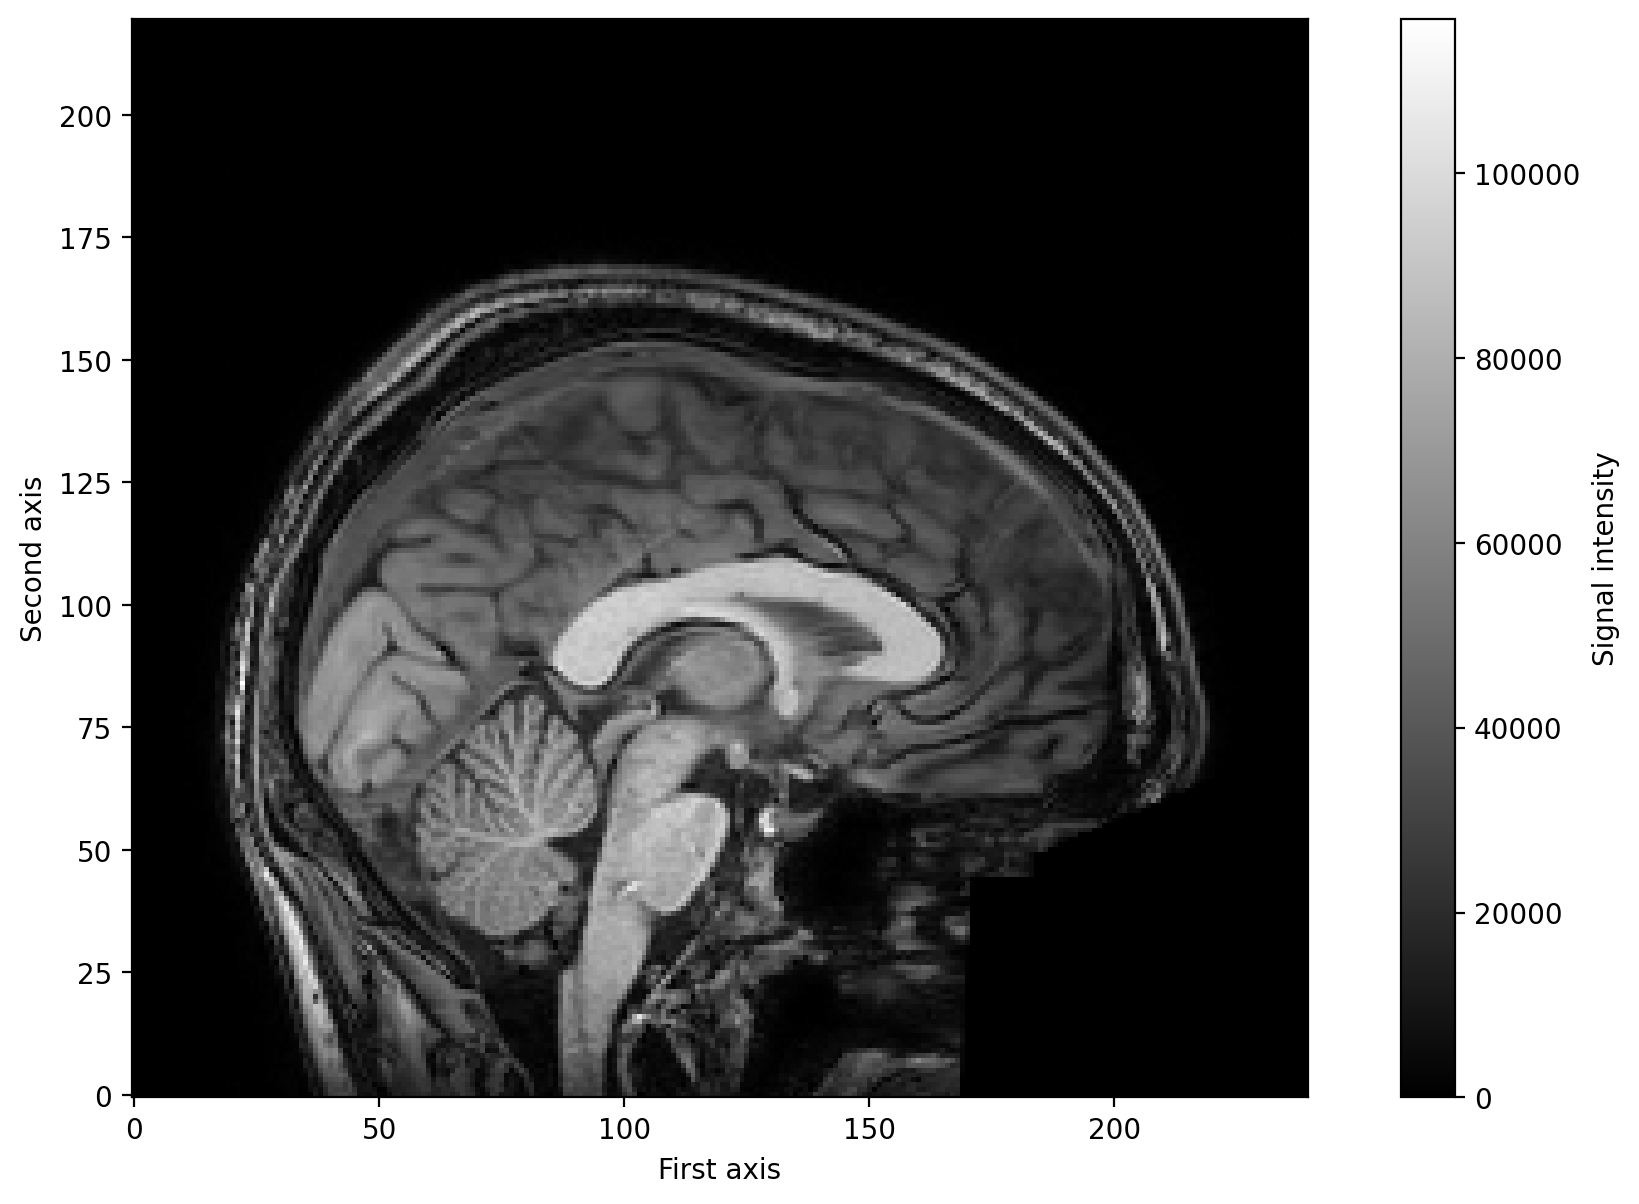

In [16]:
# Note: we transpose the slice (using .T) before plotting. 
# By default, imshow places the first array dimension on the y-axis 
# and the second on the x-axis. Here we want the opposite: 
# the first dimension on the x-axis and the second on the y-axis. 
# We also set origin="lower" because the data is stored in Cartesian coordinates.

plt.imshow(mid_slice_x.T, cmap='gray', origin='lower')
plt.xlabel('First axis')
plt.ylabel('Second axis')
plt.colorbar(label='Signal intensity')
plt.show()

Alright, time to practice.

<div class='alert alert-warning'>
<b>ToDo</b> (1 point): Use your knowledge of NumPy indexing.  
Extract the <em>second element</em> from the <em>last</em> dimension of <tt>img_data</tt> and store it in a new variable called <tt>second_slice</tt>.  

✅ Tip: if you did this correctly, <tt>second_slice</tt> will have the shape $240 \times 240$.
</div>

In [17]:
# YOUR CODE HERE
second_slice = img_data[:, :, 1]
print(second_slice.shape)

(240, 240)


The cell below provides feedback on your answer

In [18]:
if "second_slice" not in locals():
    print('The variable "second_slice" is not defined. Check that you created and named the variable correctly')
elif np.sum(second_slice) != 205076302.9866562:
    print('Hmm, something seems off. Please check your answer')
else:
    print('Well done. Your answer passed the automated tests.')

Well done. Your answer passed the automated tests.


So far, we have only worked with *structural* (3D) MRI data. Since this course focuses on analysing *functional* data, let’s now look at an fMRI scan.  

We will use the `Nifti1Image` object `func_img` from earlier and load its data into memory with the `.get_fdata()` method.  
This step takes longer than with the structural scan, because the dataset is much larger:  

- Structural data: $240 \times 240 \times 220 = 12,672,000$ values  
- Functional data: $80 \times 80 \times 44 \times 347 = 97,715,200$ values  



In [19]:
f_img_data = f_img.get_fdata()
print(f_img_data.shape)

(80, 80, 44, 50)


Anatomical scans are usually 3D, while functional scans are 4D, because they add the time dimension. You can think of this 4D array as a sequence of 3D images (volumes), with the fourth dimension representing **time** (see the illustration below).  

![](https://nilearn.github.io/stable/_images/niimgs.jpg)  

*Source: [Nilearn documentation](https://nilearn.github.io/stable/_images/niimgs.jpg)*  

In fMRI, these 3D images are often called **volumes** or **dynamics**. For example, the *first volume* is simply the first 3D brain image acquired in the time series.  

Just like with anatomical MRI, the values in fMRI data are nothing more than numbers:

In [20]:
# printing a small 3x3x3 volume of voxels from the first timepoint
print(f_img_data[38:41, 38:41, 20:23, 0])

[[[52805.65625    60819.890625   20578.92578125]
  [57084.4453125  55794.015625   17047.22851562]
  [55318.59375    54130.04296875  7301.10351562]]

 [[53111.28515625 43500.99609375 28661.07617188]
  [55488.38671875 49715.421875   20477.04882812]
  [53281.078125   50224.80078125  9304.66210938]]

 [[56846.734375   53756.5        52567.9453125 ]
  [55114.84375    55182.76171875 48798.5390625 ]
  [50055.0078125  56201.51953125 45334.76171875]]]


As with structural data, we can visualise the voxel values as images.  
The first three dimensions represent space, so we can plot slices through them, while the fourth dimension represents time.  

For example, here we display a single slice at $x = 39$ from the first volume ($t = 0$):

Shape of slice: (80, 44)


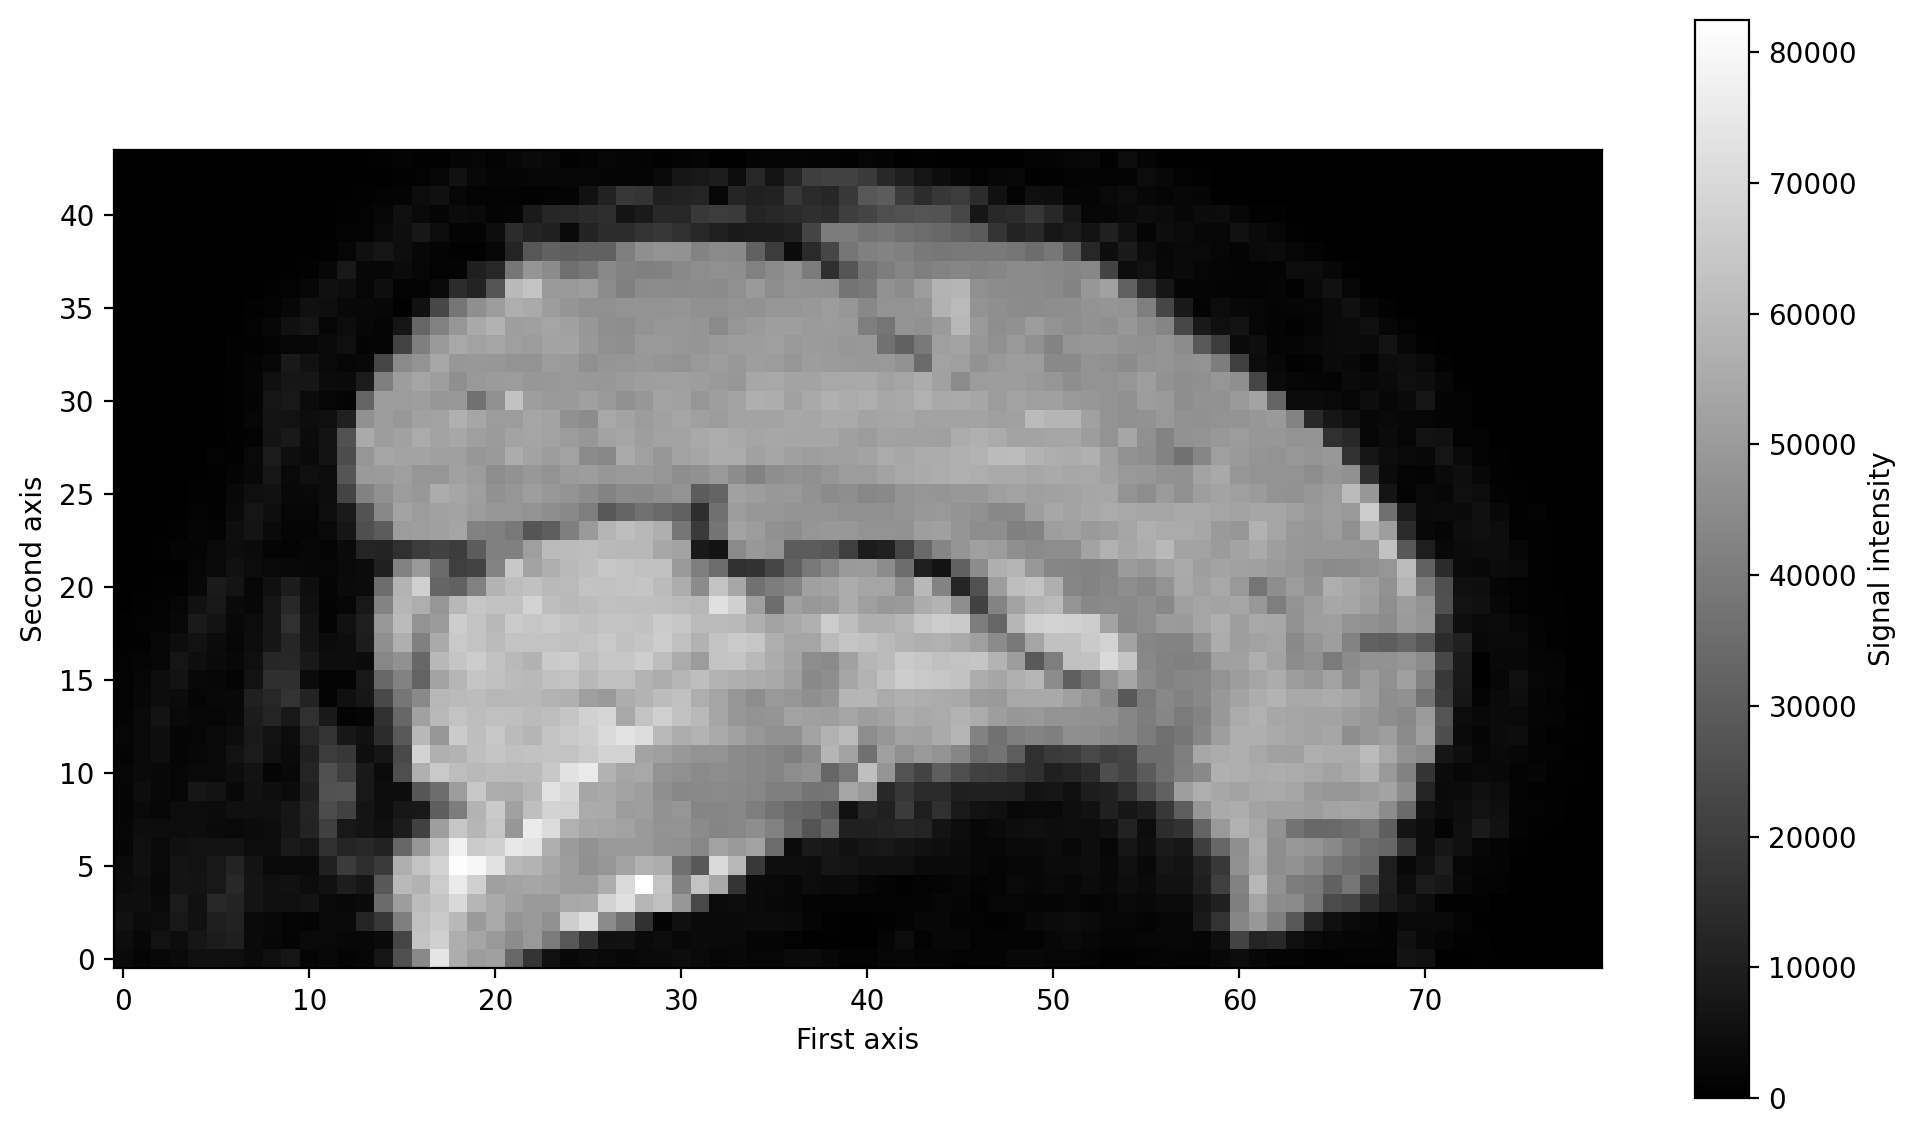

In [21]:
mid_slice_x_fmri = f_img_data[39, :, :, 0]  # x = 39, t = 0
print("Shape of slice: %s" % (mid_slice_x_fmri.shape,))

plt.imshow(mid_slice_x_fmri.T, cmap='gray', origin='lower')
plt.xlabel('First axis')
plt.ylabel('Second axis')
plt.colorbar(label='Signal intensity')
plt.show()

We can also explore fMRI data along the **time dimension**.  
Instead of looking at slices or volumes, we can examine the *time series* of a single voxel — that is, how its signal intensity changes over time. This is the basis for detecting changes in brain activity over time. 

Let’s start by extracting the time series of one specific voxel, for example, the voxel located in the middle of all three spatial dimensions (we used this voxel just as an example - there is nothing unique or spatial about this specific location):

In [22]:
mid_vox_ts = f_img_data[39, 39, 21, :]  # note the ":", saying: give me ALL the timepoints
print("Voxel timeseries shape: %s" % (mid_vox_ts.shape,))

Voxel timeseries shape: (50,)


In the previous step, we extracted the signal intensity at the *same* spatial location ($x = 39, y = 39, z = 21$) across all 347 time points.  

In the next cell, we’ll visualise this by marking the voxel’s coordinates with a red box across 20 selected time points (instead of all 347, which would make the figure too cluttered):

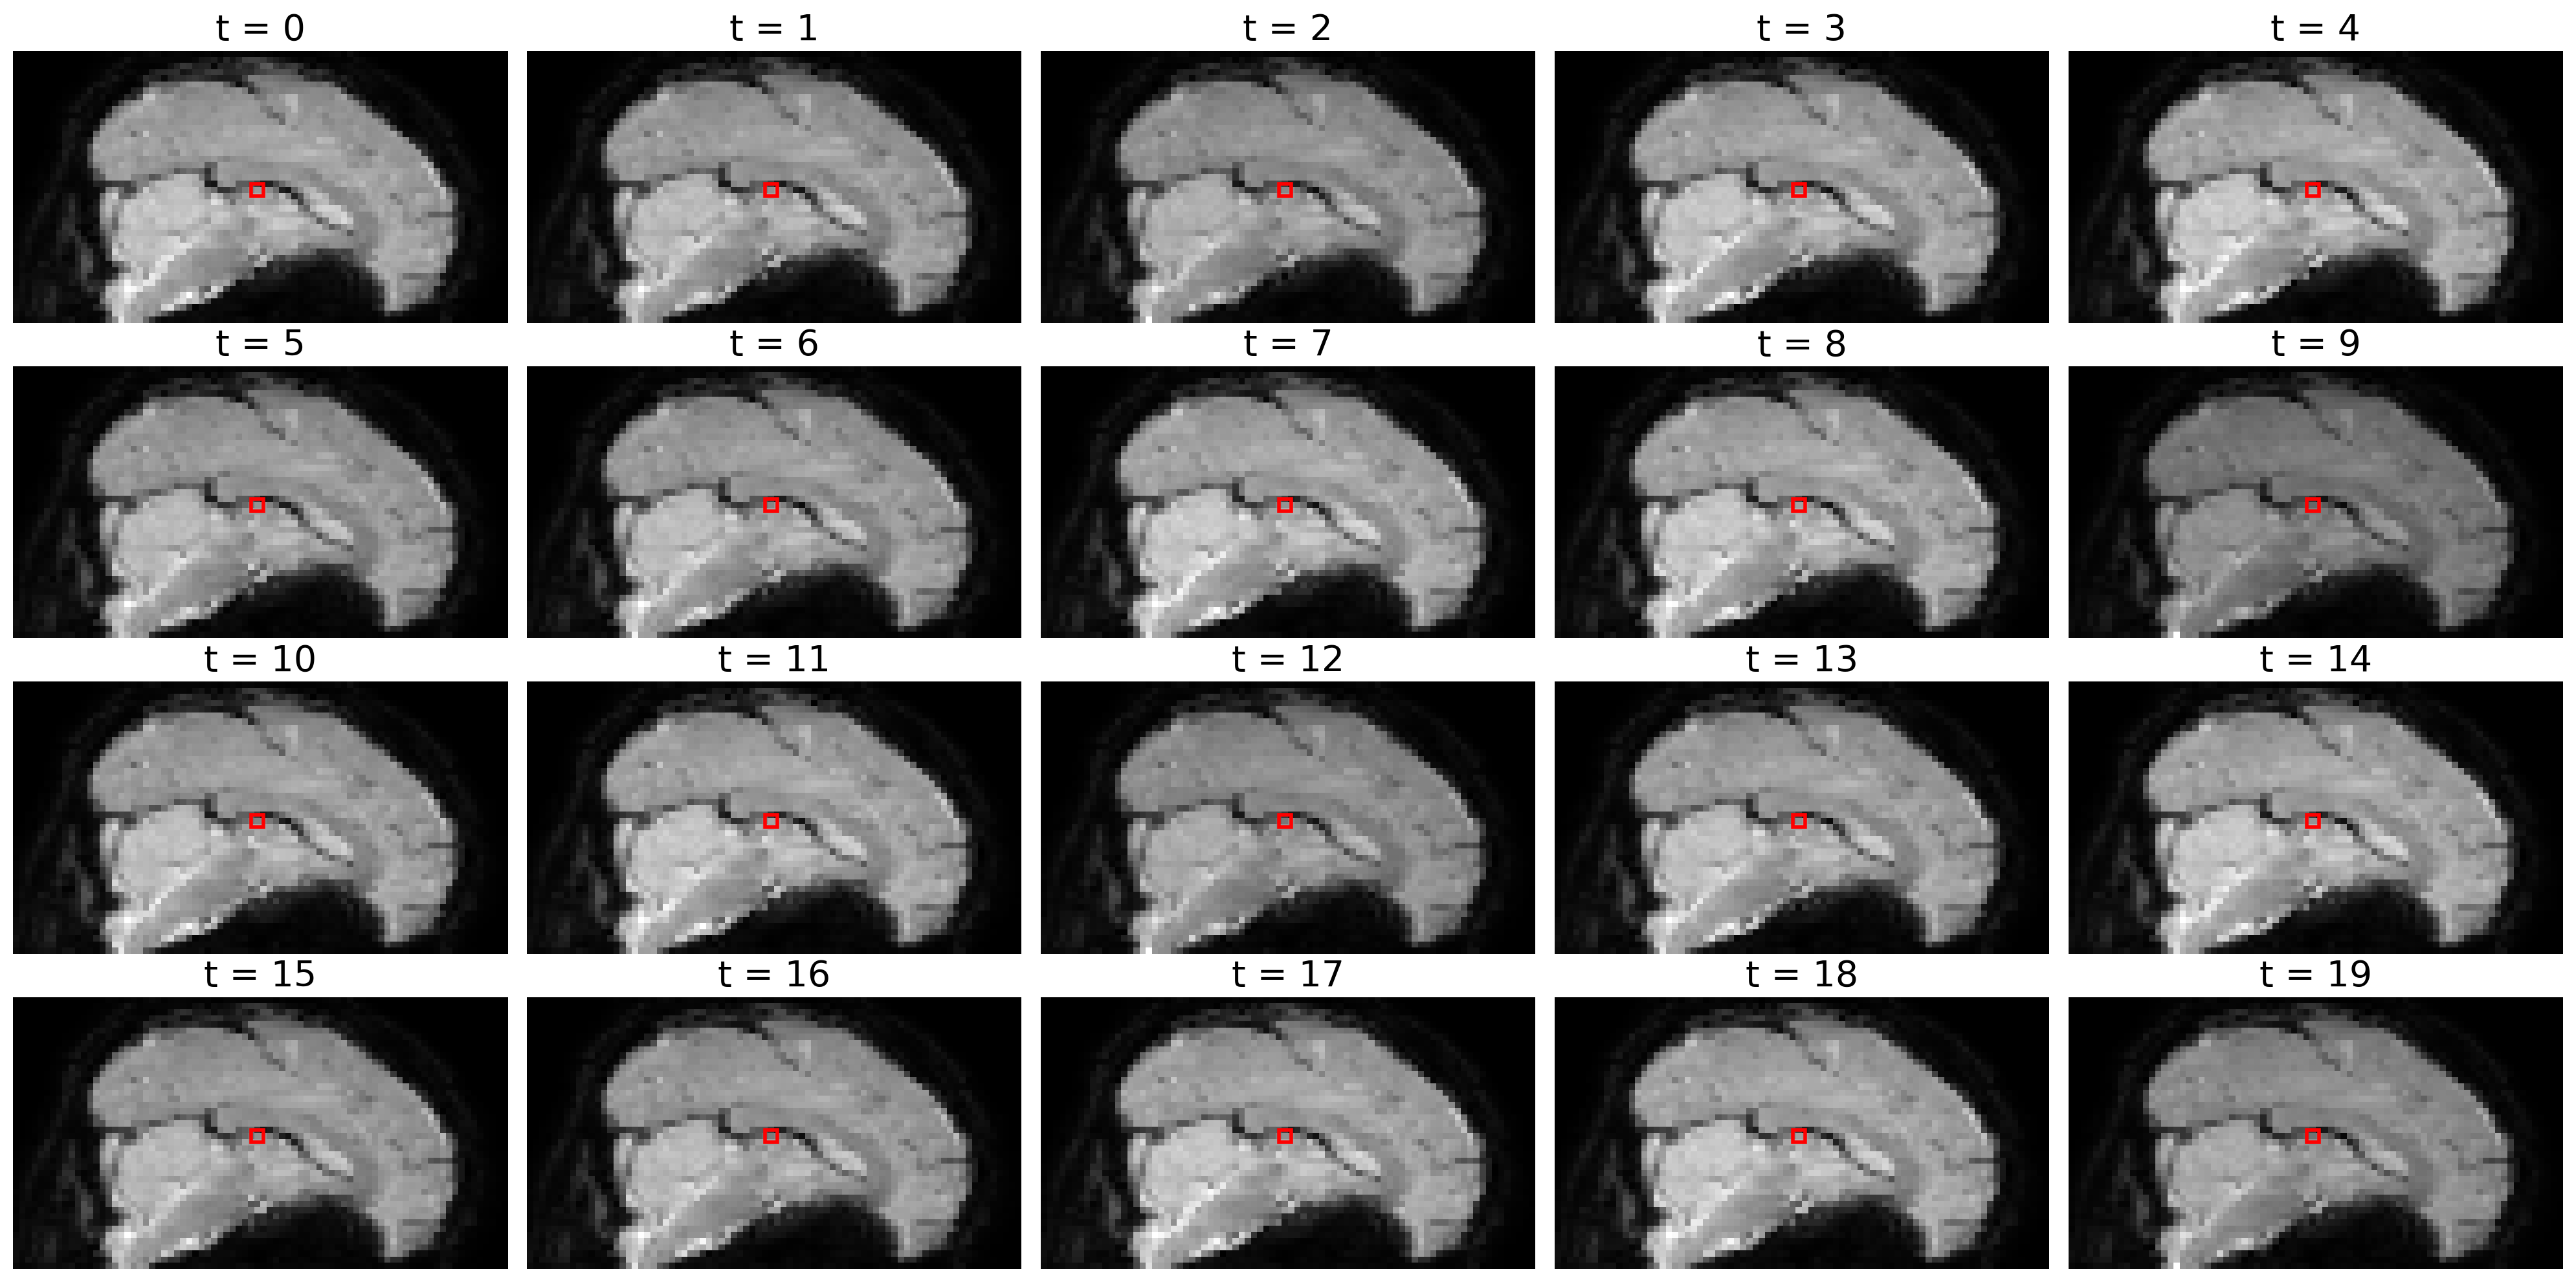

In [23]:
from matplotlib import patches

fig, axes = plt.subplots(ncols=5, nrows=4, figsize=(20, 10))  # 20 timepoints
# Loop over the first 20 volumes/timepoints
for t, ax in enumerate(axes.flatten()):    
    ax.imshow(f_img_data[39, :, :, t].T, cmap='gray', origin='lower')  # index with t!
    rect = patches.Rectangle((38, 20), 2, 2, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.axis('off')
    ax.set_title('t = %i' % t, fontsize=20)
fig.tight_layout()

It is *very* difficult to see differences between slices at different time points just by looking at the images — to the naked eye, they all look almost identical.  

This is because fMRI activity fluctuations over time are extremely small: typically only **1–3% of the baseline signal**.  
That’s why raw images don’t reveal much without further processing or scaling.  

A better way to observe these fluctuations is to plot the voxel’s time series directly:

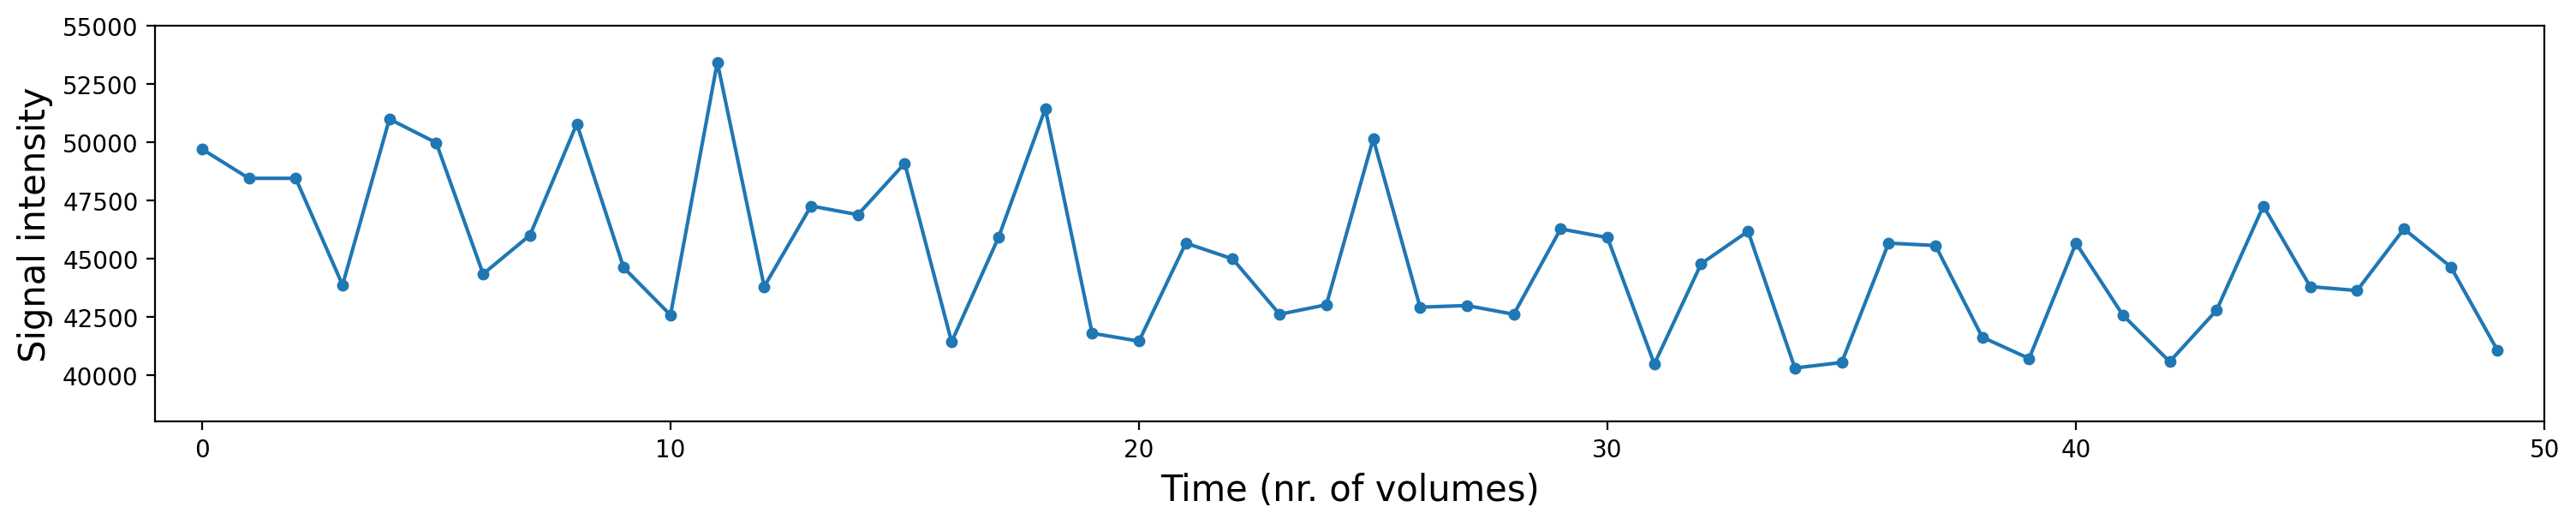

In [24]:
plt.figure(figsize=(18, 3))
plt.plot(mid_vox_ts, 'o-', ms=4)
plt.xlim(-1, mid_vox_ts.size)
plt.ylim(38000, 55000)
plt.ylabel('Signal intensity', fontsize=15)
plt.xlabel('Time (nr. of volumes)', fontsize=15)
plt.show()

In the plot above, each blue dot represents a signal intensity value (y-axis) at a given time point (x-axis).  
The connecting blue line is simply an interpolation between the points — it doesn’t add new information but makes the plot easier to read.  

Now it’s your turn: **ToDo!**

<div class='alert alert-warning'>
<b>ToDo</b> (1 point):  
From the variable <tt>f_img_data</tt>, extract the <em>odd</em> time points (i.e., indices 1, 3, 5, …) of this 4D NumPy array and store them in a new variable called <tt>f_img_data_odd</tt>.  

✅ Hint: the result should have the shape $80 \times 80 \times 44 \times 25$.
</div>

In [25]:
# YOUR CODE HERE
f_img_data_odd = f_img_data[:, :, :, 1::2] # using step by 2 to get odd time points
print(f_img_data_odd.shape)

(80, 80, 44, 25)


In [26]:
if "f_img_data_odd" not in locals():
    print('The variable "f_img_data_odd" is not defined. Check that you created and named the variable correctly')
elif np.sum(f_img_data_odd) != 79228010350.35803:
    print('Hmm, something seems off. Please check your answer')
else:
    print('Well done. Your answer passed the automated tests.')

Well done. Your answer passed the automated tests.


### The Affine

In addition to the data and metadata, each NIfTI file also contains an **affine matrix**.  
This matrix defines how image coordinates (voxel indices) map onto real-world coordinates.  

That may sound a bit abstract (it certainly did to us at first!), so let’s look at a concrete example where the affine matters.  

Imagine you receive a NIfTI file from a colleague (we’ll use the `img` variable here to represent it). You don’t know whether it even contains a brain scan, so you decide to inspect it by plotting three slices — one from each axis.  

For instance:  
- slice 70 (index 69, since Python uses zero-based indexing) along the first axis  
- slice 100 along the second axis  
- slice 100 along the third axis  

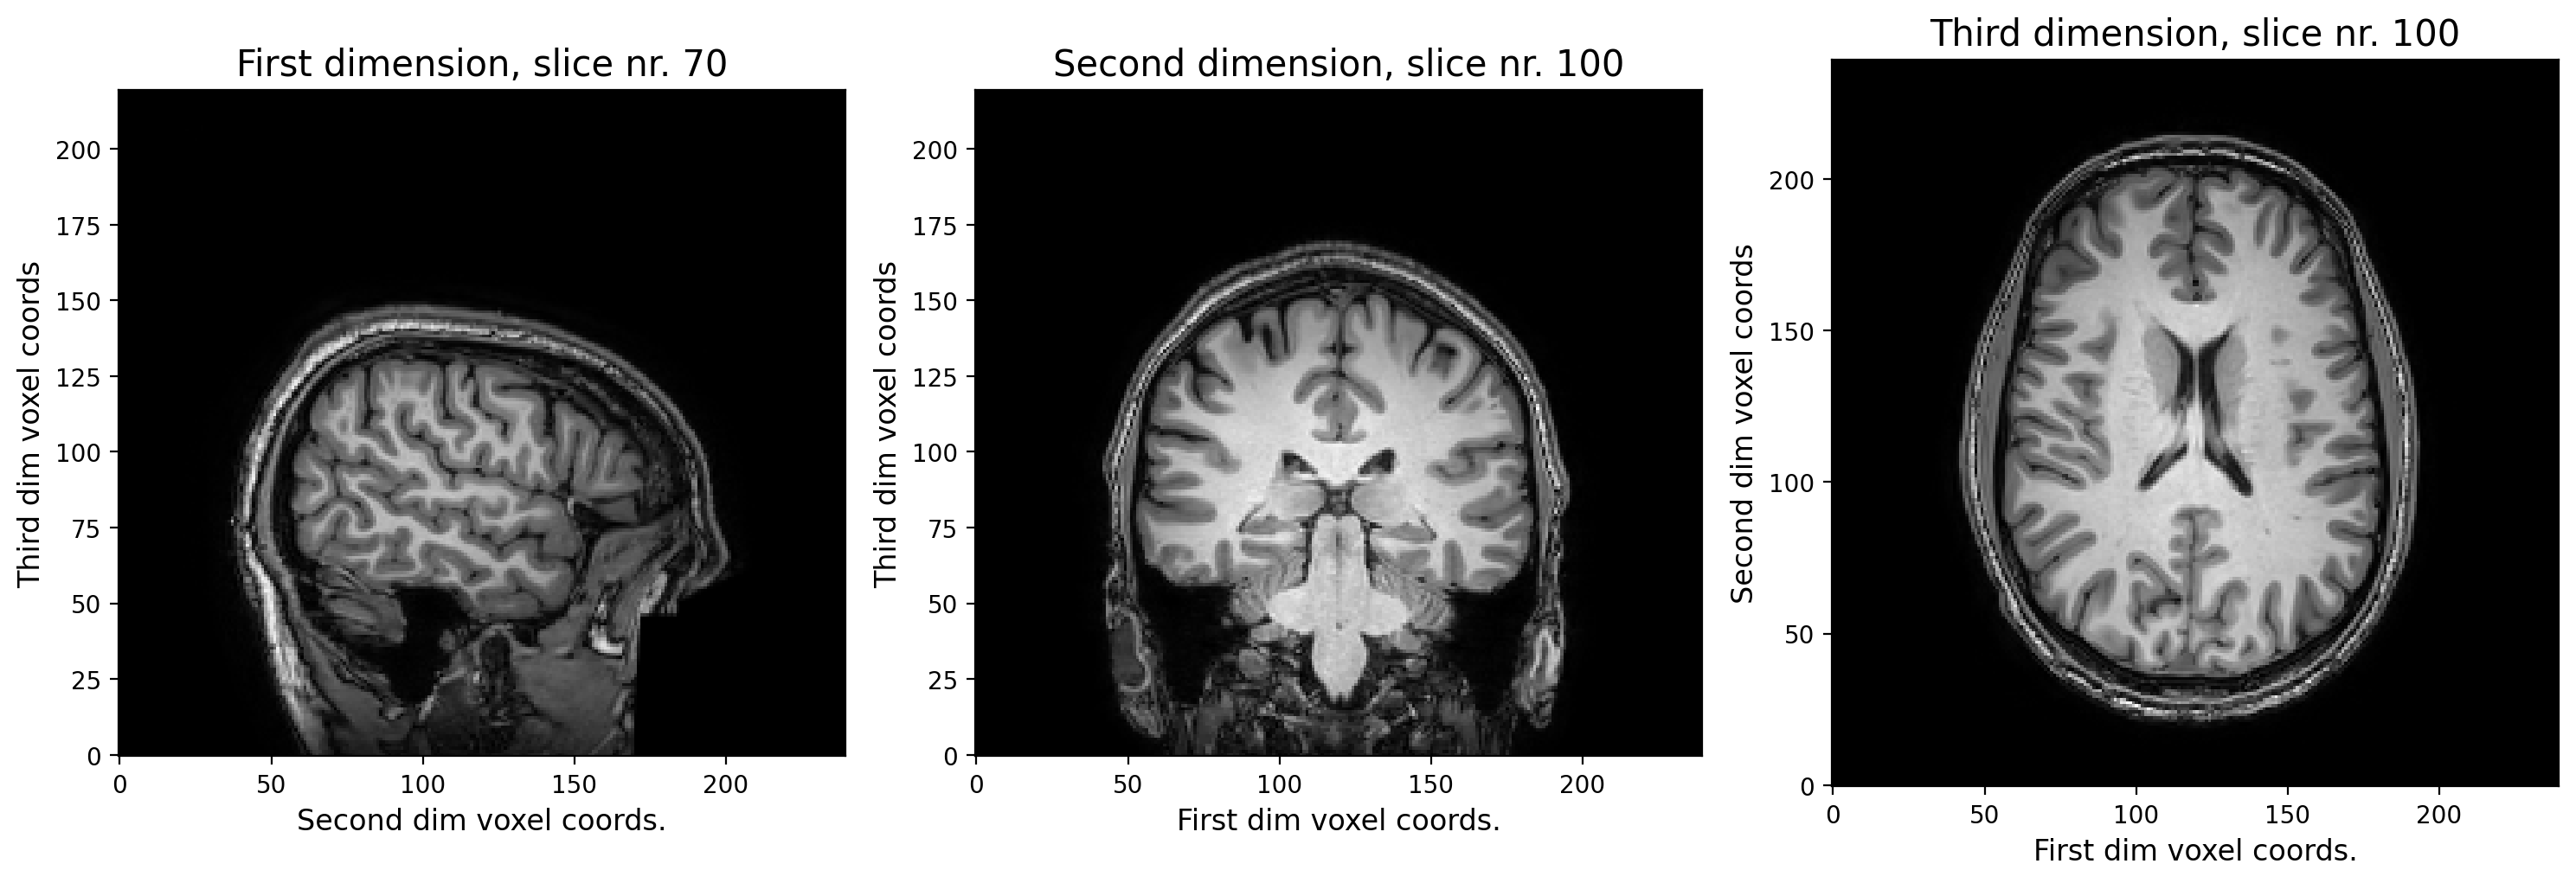

In [27]:
fig, ax = plt.subplots(ncols=3, figsize=(15, 5))

ax[0].imshow(img_data[69, :, :].T, origin='lower', cmap='gray')
ax[0].set_xlabel('Second dim voxel coords.', fontsize=12)
ax[0].set_ylabel('Third dim voxel coords', fontsize=12)
ax[0].set_title('First dimension, slice nr. 70', fontsize=15)

ax[1].imshow(img_data[:, 99, :].T, origin='lower', cmap='gray')
ax[1].set_xlabel('First dim voxel coords.', fontsize=12)
ax[1].set_ylabel('Third dim voxel coords', fontsize=12)
ax[1].set_title('Second dimension, slice nr. 100', fontsize=15)

ax[2].imshow(img_data[:, :, 99].T, origin='lower', cmap='gray')
ax[2].set_xlabel('First dim voxel coords.', fontsize=12)
ax[2].set_ylabel('Second dim voxel coords', fontsize=12)
ax[2].set_title('Third dimension, slice nr. 100', fontsize=15)

fig.tight_layout()

Alright — from the slices you plotted, it’s clear that this is a structural MRI scan.  
You can tell that:  
- the first voxel axis corresponds to the **sagittal** plane (left ↔ right)  
- the second voxel axis corresponds to the **coronal** plane (posterior ↔ anterior)  
- the third voxel axis corresponds to the **axial** plane (inferior ↔ superior)  

So far, so good!  

But here’s a tricky question: *in the first plot, are we looking at the left or the right side of the brain?*  
Because the brain is roughly symmetrical left-to-right, this is impossible to know from voxel indices alone.  

That’s where the **affine matrix** comes in. It tells us how voxel coordinates map onto **real-world coordinates** — in other words, whether “left” in voxel space corresponds to “left” in physical space.  

In this context, *real-world space* refers to the voxel positions (in millimetres) relative to the **scanner isocenter**. By convention:  
- the point $(0, 0, 0)$ is the isocenter  
- the first axis runs left → right  
- the second axis runs posterior → anterior  
- the third axis runs inferior → superior  

This is known as the **RAS+ convention**, which means:  
- positions to the **Right, Anterior, Superior** of the isocenter are positive (+)  
- positions to the **Left, Posterior, Inferior** are negative (–)

**In short**: Left = negative x, Right = positive x

![img](http://www.grahamwideman.com/gw/brain/fs/coords/FSCoords_RAS01.gif)  
(Source: Graham Wideman, [link](http://www.grahamwideman.com/gw/brain/fs/coords/fscoords.htm))  

So how does the affine help? With a simple matrix multiplication.  
If $(i, j, k)$ are voxel indices, you append a 1 to make a column vector $(i, j, k, 1)$.  
Multiplying this by the $4 \times 4$ affine matrix $A$ gives the real-world coordinates in RAS+ space:  

$$[x\; y\; z\; 1]^T = A \cdot [i\; j\; k\; 1]^T$$

Thus, every NIfTI image has a $4 \times 4$ affine matrix.  
In nibabel, this is stored as the `.affine` attribute of a `Nifti1Image`, represented as a 2D NumPy array:

In [28]:
np.set_printoptions(suppress=True, precision=3)  # suppresses scientific notation
A = img.affine
print(A)

[[  -0.999   -0.035   -0.006  122.245]
 [  -0.035    0.997    0.066 -117.457]
 [  -0.004   -0.066    0.998  -51.112]
 [   0.       0.       0.       1.   ]]


Now, suppose you want to know whether the sagittal slice shown in the leftmost plot of the previous figure corresponds to the **left** or **right** side of the brain.  

In other words, we want to determine the real-world $x$ coordinate for the voxel index $i = 69$.  
For the other two dimensions, we’ll choose the middle voxel indices ($j = 119$, $k = 109$).  
The resulting 3D coordinate will be highlighted in red in the plot below.

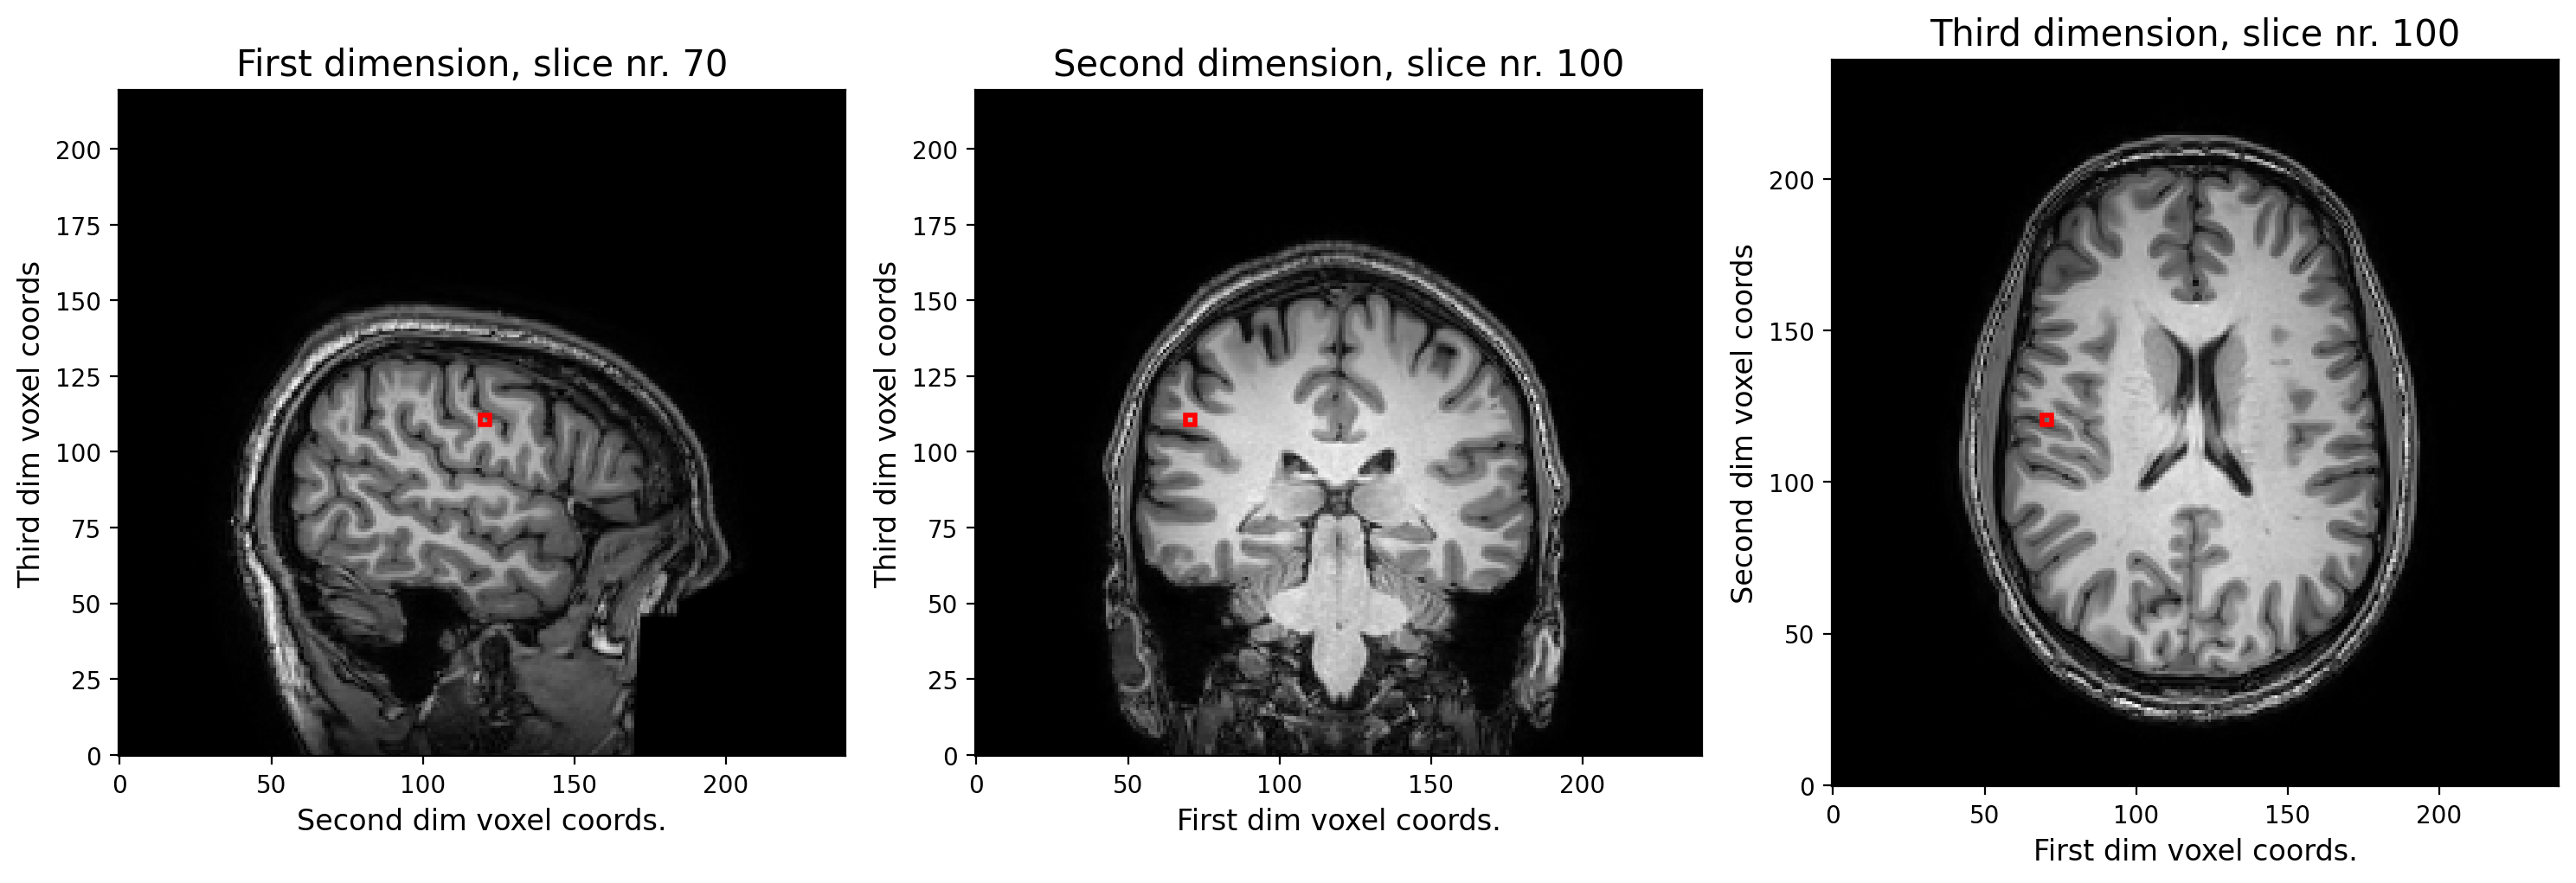

In [29]:
import matplotlib.patches as patches
fig, ax = plt.subplots(ncols=3, figsize=(15, 5))

ax[0].imshow(img_data[69, :, :].T, origin='lower', cmap='gray')
ax[0].set_xlabel('Second dim voxel coords.', fontsize=12)
ax[0].set_ylabel('Third dim voxel coords', fontsize=12)
ax[0].set_title('First dimension, slice nr. 70', fontsize=15)
rect = patches.Rectangle((119, 109), 3, 3, linewidth=2, edgecolor='r', facecolor='none')
ax[0].add_patch(rect)

ax[1].imshow(img_data[:, 99, :].T, origin='lower', cmap='gray')
ax[1].set_xlabel('First dim voxel coords.', fontsize=12)
ax[1].set_ylabel('Third dim voxel coords', fontsize=12)
ax[1].set_title('Second dimension, slice nr. 100', fontsize=15)
rect = patches.Rectangle((69, 109), 3, 3, linewidth=2, edgecolor='r', facecolor='none')
ax[1].add_patch(rect)

ax[2].imshow(img_data[:, :, 99].T, origin='lower', cmap='gray')
ax[2].set_xlabel('First dim voxel coords.', fontsize=12)
ax[2].set_ylabel('Second dim voxel coords', fontsize=12)
ax[2].set_title('Third dimension, slice nr. 100', fontsize=15)
rect = patches.Rectangle((69, 119), 3, 3, linewidth=2, edgecolor='r', facecolor='none')
ax[2].add_patch(rect)

fig.tight_layout()

To get the real world coordinate, we need to evaluate the following:
\begin{align}
x, y, z, 1 = A\begin{bmatrix}
           69 \\
           119 \\
           109 \\
           1
         \end{bmatrix}
\end{align}

Let's do that below:

In [30]:
xyz1 = A @ np.array([69, 119, 109, 1])
print(xyz1)

[48.472  5.972 49.516  1.   ]


Here we find that the real-world $x$ coordinate is **48.472**, meaning this voxel lies 48.472 millimetres to the *right* of the isocenter (recall the *RAS+* convention!).  

So why does this matter? For the statistical analysis itself, it usually doesn’t — the general linear model (GLM), which we’ll use throughout this course, doesn’t care whether a voxel is on the left or right side of the brain.  

But for **visualisation and reporting**, it’s crucial.  
For example, if you find unilateral amygdala activity for a given condition, you’ll want to know whether it’s in the **left** or **right** amygdala — both for your figures and for describing the results in a paper.  

The affine also becomes important in preprocessing steps such as **motion correction** (realigning fMRI volumes) and **registration** (aligning functional data with a structural scan or a standard brain template, which may use different orientations). We will cover this in more detail in **Week 4**.

<div class='alert alert-warning'>
<b>ToDo</b> (1 point): Suppose that you want to know whether the how much the middle of the image (i.e., the center in voxel coordinates) deviates from the isocenter of the scanner. In other words, you want to check whether the center of the image was in the isocenter of the scanner. You should do this for the <tt>img_data</tt> array! Store these world coordinates in a new array named <tt>xyz_middle</tt>, which should be of size 3 (representing the three coordinates, so make sure to remove the extra <tt>1</tt>). Remember, indexing is Python is zero-based (so the first index is 0).
</div>



In [31]:
# YOUR CODE HERE
xyz_middle = A @ np.array([119, 119, 109, 1])
xyz_middle = xyz_middle[0:3]

In [32]:
if "xyz_middle" not in locals():
    print('The variable "xyz_middle" is not defined. Check that you created and named the variable correctly')
elif np.sum(xyz_middle) != 52.03729632217437:
    print('Hmm, something seems off. Please check your answer')
else:
    print('Well done. Your answer passed the automated tests.')

Well done. Your answer passed the automated tests.


<div class='alert alert-warning'>
<b>ToDo</b> (3 points): Almost done! Let’s practise some of the skills you learned in this tutorial.  

Your task is to <em>plot a histogram of the average activity values across time for all non-zero voxels in the brain</em>, using the <tt>f_img_data</tt> array.  

Follow these steps:  
<ol>
    <li>Average the <tt>func_img_data</tt> variable across the time dimension.  
        (The resulting array should have shape <tt>(80, 80, 44)</tt>.)</li>
    <li>Remove all voxels with a value of zero (hint: use boolean indexing).</li>
    <li>Plot a histogram of the remaining non-zero voxel values, using 50 bins.</li>
</ol>

<p>Do this in the code cell below. Remember to give the plot sensible axis labels.  
This is a manually graded assignment, so there will be no automated test or feedback.</p>

<p>If done correctly, the histogram should show a <em>bimodal distribution</em> of average activity values — roughly one peak near $x = 0$ and another around $x = 42{,}000$.</p>
</div>

Averaged image shape: (80, 80, 44)
Shape after removing zeros: (210723,)


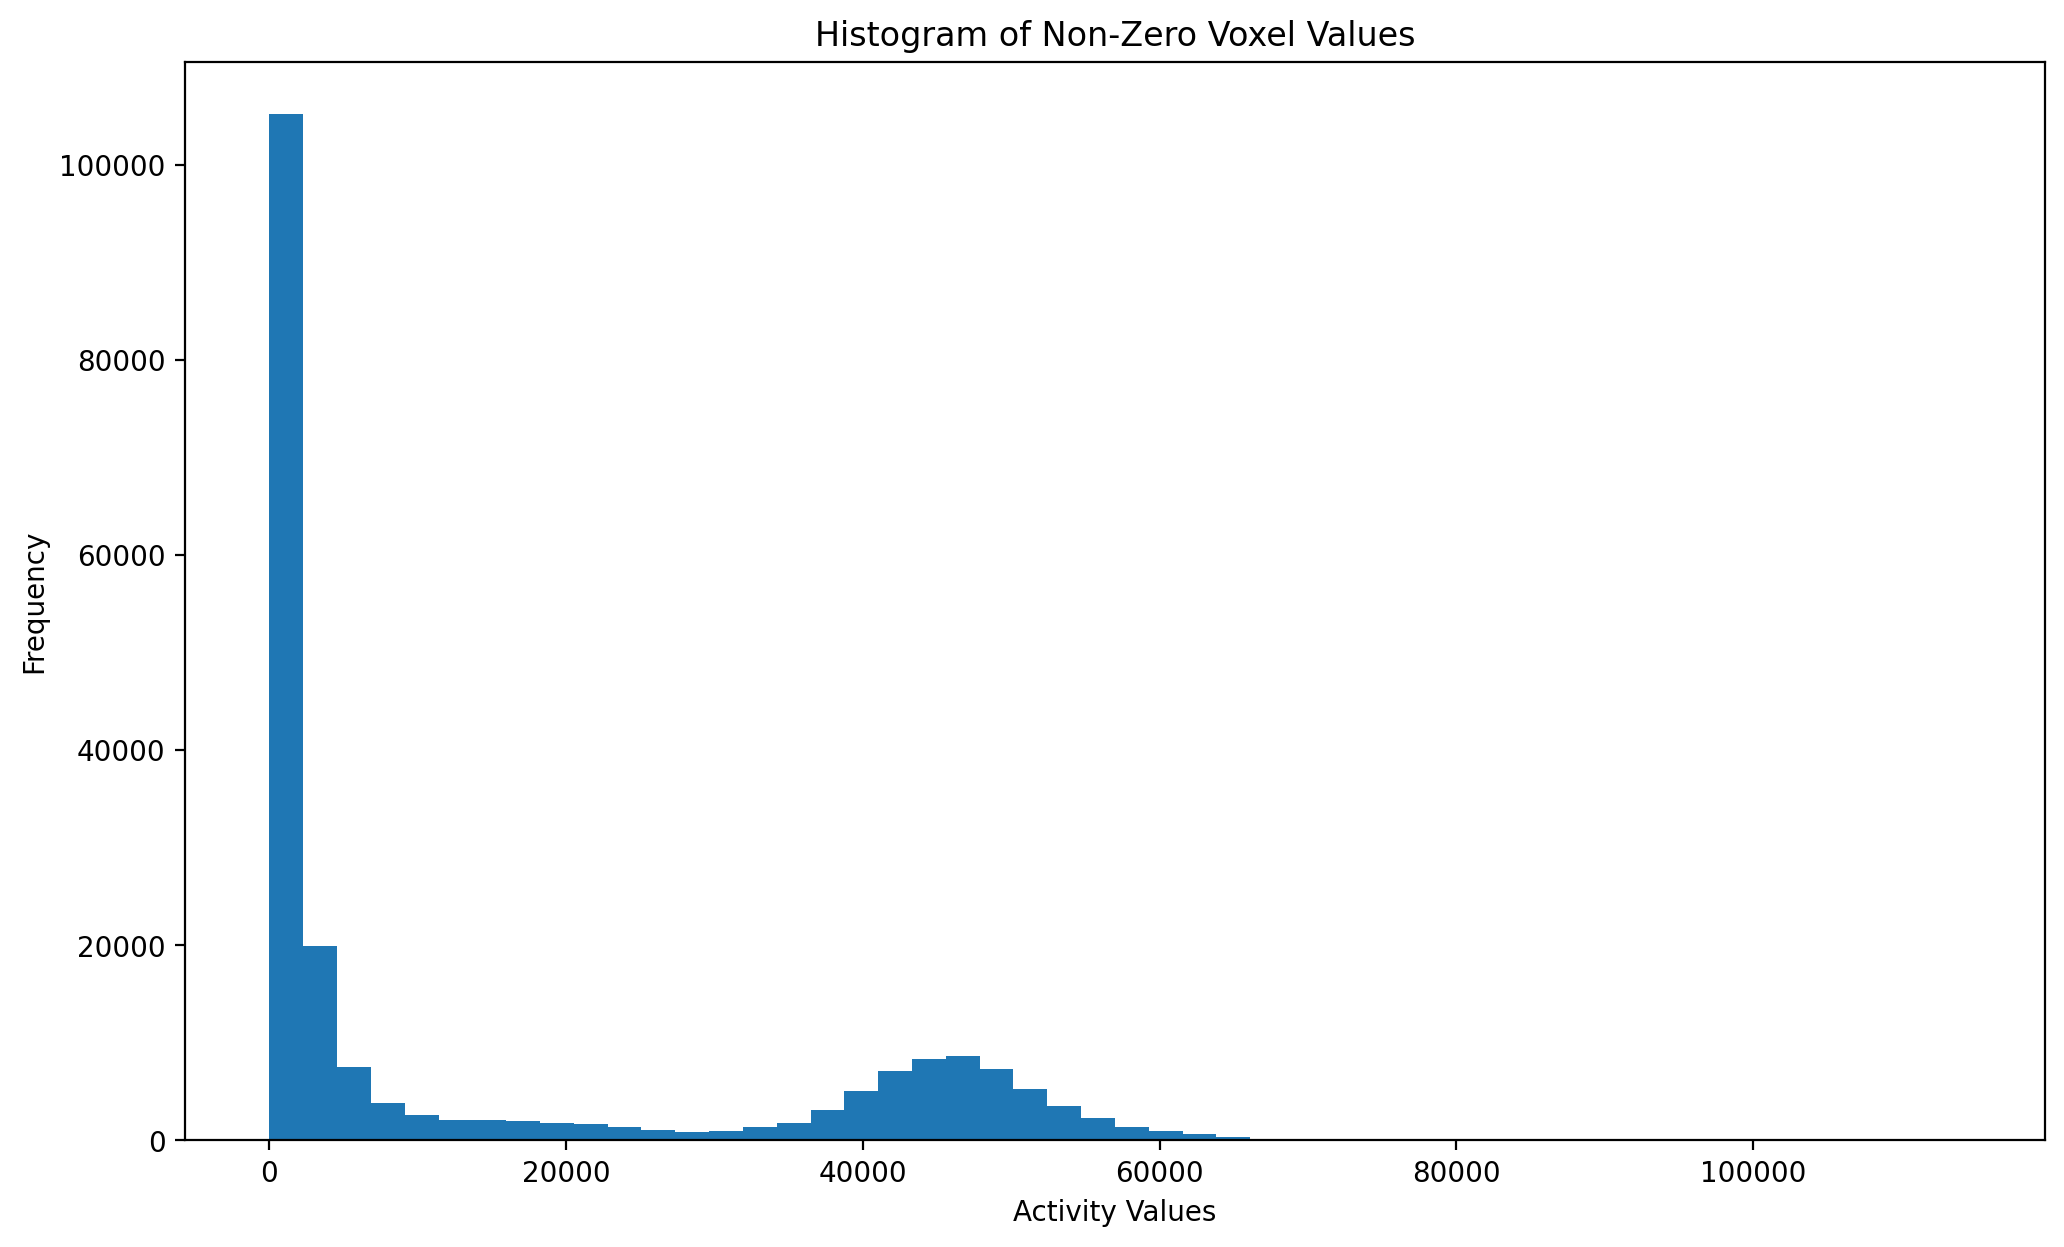

In [35]:
# YOUR CODE HERE
# Average across time dimension 
f_img_data_mean = np.mean(f_img_data, axis=3)
print("Averaged image shape:", f_img_data_mean.shape)

# Remove all voxels with a value of zero
f_img_data_nonzero = f_img_data_mean[f_img_data_mean != 0]
print("Shape after removing zeros:", f_img_data_nonzero.shape)
import matplotlib.pyplot as plt

# Plot histogram of non-zero voxel values
plt.hist(f_img_data_nonzero, bins=50)
plt.title("Histogram of Non-Zero Voxel Values")
plt.xlabel("Activity Values")
plt.ylabel("Frequency")
plt.show()

# the historgram shows a bimodal distribution of average activity values

In [34]:
# Please run this cell to clear up space on the server. If you need the data again, just run the download cell at the beginning of the notebook.

for file in ['anat.nii.gz', 'func.nii.gz']:
    if os.path.isfile(file):
        os.remove(file)
        print(f'Removed file {file}')
    else:
        print(f'File {file} not found')

Removed file anat.nii.gz
Removed file func.nii.gz


## 🎉 Well done!  

You’ve completed this week’s notebook.

In this session, you worked with several core Python packages for data handling, analysis, and visualisation — including **NumPy**, **SciPy**, and **Matplotlib**.  
These tools form the foundation we’ll keep using throughout the course.  

Later on, we’ll also introduce higher-level libraries such as [**Nilearn**](https://nilearn.github.io/), which make many common neuroimaging tasks (like fMRI preprocessing and statistical analysis) faster and easier to implement.

----
### Up next: Week 2  

Next week we dive into the **General Linear Model (GLM)** — the statistical backbone of most univariate fMRI analyses.  
We’ll focus on the *estimation* step: how to estimate parameters and evaluate model fit.  

By the end of Week 2, you will:  
- know how to estimate and interpret parameters in a GLM,  
- understand why the BOLD response needs to be modelled within the GLM, and  
- be able to implement and apply the GLM to univariate fMRI data.  

Next week is a bit maths-heavy, but don’t worry. We’ll work through the formulas step by step and reinforce each concept with code examples and exercises.

<div class='alert alert-success'>
    <b>Tip</b>: When you are finished with your work, click "Validate" at the top of the notebook. This will run the entire notebook and tell you with there are any errors.
</div>

